# 04. Linear models

**Context**
- Baselines (NB03) grow smoothly with horizon; geometric extrapolation alone is insufficient.
- Lookback fixed at **12h**.
- The useful lag count is open.

**Objective**
- Test a regularized linear model (Ridge, L2 for the collinear lags) on the base features.
- Find the useful number of lags.
- Read both MAE and the operational R(p,h).

**Outcome**
- Lag count plateaus at **6**.
- Ridge lowers MAE modestly over baseline (about **+13%** at 48–72h, slightly negative at 2h) and roughly halves the R90 search area from 12h on.
- Baseline keeps a lower R50 on easy tracks; Ridge has a heavier extreme tail.
- The ceiling is what a linear map can express, which motivates a non-linear model (NB05).


## Contents

1. Setup
2. Data and code prep
3. Model evaluation across horizons and lags
4. Conclusion
5. Appendix


## 1. Setup


In [56]:
import gc
import time
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

from vessel_tracker.config import settings
from vessel_tracker.paths import DATA_PROCESSED
from vessel_tracker.preprocessing import vessel_train_test_split
from vessel_tracker.metrics import haversine_distance

# --- Load cleaned + resampled dataset (NB02) ---
processed_path = DATA_PROCESSED / f"AIS_clean_resampled_{settings.resample_interval_min}min.parquet"
df = pd.read_parquet(processed_path)
df["BaseDateTime"] = pd.to_datetime(df["BaseDateTime"])

#downcasting to save RAM
float_cols = ["LAT", "LON", "SOG", "Heading", "Length", "Width", "Draft"]
df[float_cols] = df[float_cols].astype("float32") #to avoid OOM
df["MMSI"] = df["MMSI"].astype("int32")

print(f"Loaded: {len(df):,} rows, {df['MMSI'].nunique():,} vessels")

# --- Replay the split (same seed → same partition as NB02) ---
df_train, df_val, df_test, *_ = vessel_train_test_split(df)
print(f"Train: {df_train['MMSI'].nunique():,} vessels | "
      f"Val: {df_val['MMSI'].nunique():,} | Test: {df_test['MMSI'].nunique():,}")

Loaded: 3,661,057 rows, 2,173 vessels
Train: 1,521 vessels | Val: 326 | Test: 326


## 2. Data and code prep
- merge df_train and df_val (here, the val set is created in the crossval)
- function to create target and lag features
- function to run crossval and assess model perf



### 2.1 merge df


In [57]:
df_trainval = pd.concat([df_train, df_val], axis= 0)

### 2.2 Function to create lag feature
- features evenly spaced along lookback windows


In [58]:
def create_lag_features(df, nb_lags: int, lookback_minutes: int):
    """
    Add evenly spaced lag features (LAT_lag_i, LON_lag_i) for each vessel.

    Parameters:
    -----------
    df : DataFrame
        Must contain MMSI, LAT, LON.
    nb_lags : int
        Number of lag columns to generate (2 to available_lags).
    lookback_minutes : int
        Lookback duration in minutes, converted to steps via settings.resample_interval_min.

    Returns:
    --------
    DataFrame
        Same rows minus warm-up rows without a full lookback. LAT/LON are replaced
        by LAT_lag_i / LON_lag_i columns (lag 0 is the current position).
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min
    available_lags = lookback_steps + 1
    #check if there are enough time steps for the number of lags required
    if not (2 <= nb_lags <= available_lags):
        raise ValueError(f"nb_of_lags={nb_lags} does not fit lookback_steps={lookback_steps}: "
            f"expected 1..{available_lags}.")

    #generate lags evenly spaced

    lags = np.unique(np.linspace(0, lookback_steps, nb_lags).round().astype(int))
    if len(lags) != nb_lags:
        raise ValueError(
            f"rounding over a {lookback_steps}-step window reduced the number of lags"
            f"number of lags asked : {nb_lags} number of lags obtained: {len(lags)}"

        )


    vessels  = df.groupby("MMSI")
    #create dictionnary of lag feature name : lag feature value
    lag_col = {f"{coord}_lag_{lag}": vessels[coord].shift(lag)
               for lag in lags
               for coord in ("LAT", "LON")
               }
    df = df.assign(**lag_col).drop(columns= ["LAT", "LON"]).dropna(axis= 0)
    return df


In [59]:
def create_heading_features(df):
    """
    Cyclical encoding of compass heading (degrees to sin/cos).

    Parameters:
    -----------
    df : DataFrame
        Must contain Heading (degrees, 0-360).

    Returns:
    --------
    DataFrame
        Same df with Heading replaced by Heading_sin and Heading_cos.
    """
    heading_rad = np.radians(df["Heading"])
    df = df.assign(
        Heading_sin=np.sin(heading_rad),
        Heading_cos=np.cos(heading_rad),
    )
    
    df = df.drop(columns= ["Heading"])
    return df

### 2.3 Function to create targets

Per NB01 we train **one model for all horizons**, so we put the targets for every horizon in the **same** long-format dataframe: one row per (present, horizon).

#### Approach for modeling

We predict and compare a **predicted velocity**, not the predicted future LAT/LON coordinates. The position is reconstructed afterwards as `pos(t) + v * h`. Here is the rationale:

- **Boundary behavior at small h is automatic.** As h -> 0, the true future position must converge to the present position. If the model predicted `LAT_target`/`LON_target` directly, it would have to learn this convergence itself, for every horizon, on top of everything else. By predicting a rate and reconstructing `pos(t) + v*h`, this convergence is automatic. The idea is to offload the model from having to learn simple deterministic facts.

- **LAT/LON carry no behavioral signal on their own.** A latitude of 3 vs. 99 says nothing about how a vessel moves: it's just where it happens to be on the globe. vx/vy are relative to the vessel's own present position, so the target is purely about behavior (speed, heading), not about an arbitrary geographic offset the model would otherwise have to reproduce.

- **Consistent target scale across pooled horizons.** We train on one long dataframe covering every h (see above). If the target were `Δposition = pos(t+h) - pos(t)`, its magnitude would grow with h, and a single pooled loss would end up dominated by long-horizon rows. `v = Δposition / h` stays on a comparable scale whether h is small or large, so short and long horizons weigh in more evenly.

- **Directly comparable to the baseline.** The deterministic baselines (NB03) also compute a velocity internally before reconstructing a position. Predicting the same intermediate quantity keeps model vs. baseline comparisons coherent.


In [60]:
def create_target(df: pd.DataFrame, horizon_grid_minutes: list[int]):

    """
    Build a long-format DataFrame of velocity targets for a list of prediction horizons.

    Parameters:
    -----------
    df : DataFrame
        Must already contain lag features, including LAT_lag_0 and LON_lag_0
        (current position) and columns MMSI, BaseDateTime.
    horizon_grid_minutes : list[int]
        Requested prediction horizons in minutes. Rounded to the nearest multiple
        of settings.resample_interval_min, deduplicated, and horizons rounding to
        0 are dropped. Raises ValueError if none remain.

    Returns:
    --------
    DataFrame
        One row per (source row, usable horizon). Added columns:
        vx, vy (deg/min velocity targets), h (effective horizon in minutes).
        Rows without a future position (end of track) are dropped.
    """
    horizons = np.asarray(horizon_grid_minutes)
    h_steps = np.unique(np.round(horizons / settings.resample_interval_min)).astype(int)
    h_steps = h_steps[h_steps > 0]  # drop horizons that round to 0 steps
    if len(h_steps) == 0:
        raise ValueError("no prediction horizon > 0")

    required_cols = ["MMSI", "BaseDateTime", "LAT_lag_0", "LON_lag_0"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df.sort_values(by=["MMSI", "BaseDateTime"]).reset_index(drop=True)

    lat0 = df["LAT_lag_0"].to_numpy()
    lon0 = df["LON_lag_0"].to_numpy()
    grp = df.groupby("MMSI")

    # Build small target tables only (row_id, vx, vy, h), one per horizon.
    # Avoids copying the full feature columns H times inside the loop; we attach
    # features once at the end via row_id,.
    target_parts = []
    for h_step in h_steps:
        lat_fut = grp["LAT_lag_0"].shift(-h_step).to_numpy()
        lon_fut = grp["LON_lag_0"].shift(-h_step).to_numpy()
        #we control dtype to avoid having everything in float64 (OOM crash)
        dt = int(h_step * settings.resample_interval_min)  # int: avoid float64 upcast
        #list of df: one df per horizon
        target_parts.append(pd.DataFrame({
            "row_id": np.arange(len(df), dtype=np.int64),  # create key (row position in original df)
            "vx": (lon_fut - lon0) / dt,  # mean deg/min from present to future
            "vy": (lat_fut - lat0) / dt,
            "h": np.int16(dt),  # horizon in minutes
        }))

    #concat the df 
    targets = pd.concat(target_parts, ignore_index=True).dropna(subset=["vx", "vy"])

    # Expand features: one copy of each source row per surviving (row, horizon)
    df_out = df.iloc[targets["row_id"].to_numpy()].reset_index(drop=True) #the features are duplicated for each time a given row_id appears (one occurence per horizon)
    df_out["vx"] = targets["vx"].to_numpy()
    df_out["vy"] = targets["vy"].to_numpy()
    df_out["h"] = targets["h"].to_numpy()
    return df_out


In [61]:
df_check = create_lag_features(df=df_trainval.head(1000), nb_lags=6, lookback_minutes=720)
df_check = create_heading_features(df=df_check)
df_check = create_target(df=df_check, horizon_grid_minutes=[600])
#check that the dtype are correct. 
print(df_check.dtypes)

MMSI                     int32
BaseDateTime    datetime64[ns]
SOG                    float32
Status                 float64
Length                 float32
Width                  float32
Draft                  float32
LAT_lag_0              float32
LON_lag_0              float32
LAT_lag_14             float32
LON_lag_14             float32
LAT_lag_29             float32
LON_lag_29             float32
LAT_lag_43             float32
LON_lag_43             float32
LAT_lag_58             float32
LON_lag_58             float32
LAT_lag_72             float32
LON_lag_72             float32
Heading_sin            float32
Heading_cos            float32
vx                     float32
vy                     float32
h                        int16
dtype: object


### 2.4 Functions to evaluate the baseline and the model

- one function to evaluate baseline on a val set 
- one function to fit and eval the model 
- Note: the baseline and the model predict a future straight line velocity, that is then used to calculated the predicted LAT,LON coordinates.


In [62]:
def evaluate_baseline_fold(X_val, lookback_minutes):
    """
    Compute baseline (constant-velocity extrapolation) predicted velocity for one fold.

    Extrapolates from lag_0 (current position) and lag_lookback_steps (oldest
    lookback position), expressed as a velocity in deg/minute (same unit as vx, vy).

    Parameters:
    -----------
    X_val : DataFrame
        Validation fold features. Must contain LAT_lag_0, LON_lag_0,
        LAT_lag_{lookback_steps}, LON_lag_{lookback_steps}.
    lookback_minutes : int
        Lookback duration in minutes.

    Returns:
    --------
    dict
        vx_pred : ndarray, shape (n_val,), extrapolated longitude velocity (deg/min)
        vy_pred : ndarray, shape (n_val,), extrapolated latitude velocity (deg/min)
        inference_time_s : float, wall-clock seconds for the extrapolation computation
    """
    lookback_steps = lookback_minutes // settings.resample_interval_min

    required_cols = [
        "LAT_lag_0", "LON_lag_0",
        f"LAT_lag_{lookback_steps}", f"LON_lag_{lookback_steps}",
    ]
    missing = [col for col in required_cols if col not in X_val.columns]
    if missing:
        raise ValueError(f"Missing required columns in X_val: {missing}")

    t0 = time.perf_counter()

    LAT_now = X_val["LAT_lag_0"]
    LON_now = X_val["LON_lag_0"]
    LAT_old = X_val[f"LAT_lag_{lookback_steps}"]
    LON_old = X_val[f"LON_lag_{lookback_steps}"]

    vy_pred = (LAT_now - LAT_old) / lookback_minutes
    vx_pred = (LON_now - LON_old) / lookback_minutes

    inference_time_s = time.perf_counter() - t0

    return {
        "vx_pred": vx_pred.to_numpy(),
        "vy_pred": vy_pred.to_numpy(),
        "inference_time_s": inference_time_s,
    }


In [63]:
def evaluate_model_fold(X_train, y_train, X_val, estimator):
    """
    Fit estimator on one training fold, predict velocity (vx, vy) on the validation fold.

    Parameters:
    -----------
    X_train, y_train : DataFrame
        Training fold features and targets, y_train columns [vx, vy].
    X_val : DataFrame
        Validation fold features.
    estimator : sklearn estimator
        Base estimator, wrapped in MultiOutputRegressor internally.

    Returns:
    --------
    dict
        vx_pred : ndarray, shape (n_val,), predicted longitude velocity (deg/min)
        vy_pred : ndarray, shape (n_val,), predicted latitude velocity (deg/min)
        fit_time_s : float, wall-clock seconds for model.fit
        inference_time_s : float, wall-clock seconds for model.predict
    """
    model = MultiOutputRegressor(estimator=estimator)
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time_s = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_val)
    inference_time_s = time.perf_counter() - t0

    return {
        "vx_pred": y_pred[:, 0],
        "vy_pred": y_pred[:, 1],
        "fit_time_s": fit_time_s,
        "inference_time_s": inference_time_s,
    }


### 2.5 Function to run the crossval comparison
- the same splits are made for all the estimators to evaluate, to maintain comparability
- we use the haversine MAE as metrics, but also the % of improvement of a model perf over baseline, as well as the % of error relatively to the true displacement of a vessel: this helps scale the error to the vessel's movement. 
- As operational metrics, we use the radius of uncertainty R(p,h) as described in Notebook 01 


In [64]:
def run_crossval(
    df,
    model,
    model_name: str,
    lookback_minutes,
    n_splits: int = 5,
    random_state: int = None,
    with_baseline: bool = True,
):
    """
    Run GroupKFold cross-validation for a single model (and optionally the baseline)
    on a long-format dataframe covering one or several horizons h. Reconstructs
    positions and the per-row haversine error (error_km) once, here.

    Parameters:
    -----------
    df : DataFrame
        Long-format frame from create_target (+ create_lag_features + create_heading_features).
        Must contain MMSI, BaseDateTime, vx, vy, h, Heading_sin, Heading_cos.
    model : sklearn estimator
        Base estimator for the candidate model (wrapped in MultiOutputRegressor internally).
    model_name : str
        Name used to tag the model's rows in oof_df (e.g. "Ridge").
    lookback_minutes : int
        Lookback duration in minutes, forwarded to evaluate_baseline_fold.
    n_splits : int
        Number of GroupKFold splits (grouped on MMSI).
    random_state : int, optional
        Shuffle seed; defaults to settings.random_seed.
    with_baseline : bool
        If True, also evaluate the constant-velocity baseline on every fold.

    Returns:
    --------
    oof_df : DataFrame
        One row per (out-of-fold observation, predictor). Columns:
        model_name, MMSI, h, LAT_lag_0, LON_lag_0, vx_true, vy_true, vx_pred, vy_pred,
        error_km.
    timings : DataFrame
        One row per candidate. Columns: model_name, fit_time_s, inference_time_s
        (mean over folds). Not saved downstream in this notebook.
    """
    
    #sanity check: check if feature and target are present
    required_cols = ["MMSI", "BaseDateTime", "vx", "vy", "h", "Heading_sin", "Heading_cos"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if random_state is None:
        random_state = settings.random_seed

    # shuffle rows to break MMSI ordering; reset_index so that positional and label indexing stay aligned
    df = df.copy().sample(frac=1, random_state=random_state).reset_index(drop=True)

    feature_cols = [col for col in df.columns if col.startswith(("LAT_lag", "LON_lag"))]
    feature_cols += ["SOG", "Heading_sin", "Heading_cos", "Length", "Width", "Draft", "h"]

    X = df[feature_cols]
    y = df[["vx", "vy"]]
    groups = df["MMSI"]

    # group split to avoid vessel-level leakage
    gkf = GroupKFold(n_splits=n_splits)

    candidate_names = [model_name] + (["Baseline"] if with_baseline else [])
    
    # fold wall-clock times (returned but not persisted in this notebook)
    fold_timings = {
        name: {"fit_time": [], "inference_time": []}
        for name in candidate_names
    }
    
    oof_parts = [] #for storage of out of fold data (val set)

    #crossval 
    for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]

        # keep this info from the val set to the output (will be useful for position calculation and stratified analysis)
        passthrough = df.iloc[val_idx][["MMSI", "h", "LAT_lag_0", "LON_lag_0", "vx", "vy"]]
        passthrough = passthrough.rename(columns={"vx": "vx_true", "vy": "vy_true"})

        model_result = evaluate_model_fold(X_train, y_train, X_val, model)
        fold_timings[model_name]["fit_time"].append(model_result["fit_time_s"])
        fold_timings[model_name]["inference_time"].append(model_result["inference_time_s"])

        # store the results and predictions of the val set of THIS fold
        model_part = passthrough.copy()
        model_part["model_name"] = model_name
        model_part["vx_pred"] = model_result["vx_pred"] #vx_pred is an array, will align positionally, not by index
        model_part["vy_pred"] = model_result["vy_pred"]
        oof_parts.append(model_part) 

        #add baseline prediction as well
        if with_baseline:
            baseline_result = evaluate_baseline_fold(X_val, lookback_minutes)
            fold_timings["Baseline"]["fit_time"].append(0.0)
            fold_timings["Baseline"]["inference_time"].append(baseline_result["inference_time_s"])

            baseline_part = passthrough.copy()
            baseline_part["model_name"] = "Baseline"
            baseline_part["vx_pred"] = baseline_result["vx_pred"]
            baseline_part["vy_pred"] = baseline_result["vy_pred"]
            oof_parts.append(baseline_part)

    # concat vertically the val set results from all folds
    oof_df = pd.concat(oof_parts, ignore_index=True)[
        ["model_name", "MMSI", "h", "LAT_lag_0", "LON_lag_0", "vx_true", "vy_true", "vx_pred", "vy_pred"]
    ]

    # reconstruct positions and the haversine error once, here, so no other
    # function needs to touch position space or recompute error_km
    LON_pred = oof_df["LON_lag_0"] + oof_df["vx_pred"] * oof_df["h"]
    LAT_pred = oof_df["LAT_lag_0"] + oof_df["vy_pred"] * oof_df["h"]
    LON_true = oof_df["LON_lag_0"] + oof_df["vx_true"] * oof_df["h"]
    LAT_true = oof_df["LAT_lag_0"] + oof_df["vy_true"] * oof_df["h"]
    oof_df["error_km"] = haversine_distance(
        LAT_true.to_numpy(), LON_true.to_numpy(), LAT_pred.to_numpy(), LON_pred.to_numpy()
    )

    timings = pd.DataFrame([
        {
            "model_name": name,
            "fit_time_s": float(np.mean(fold_timings[name]["fit_time"])),
            "inference_time_s": float(np.mean(fold_timings[name]["inference_time"])),
        }
        for name in candidate_names
    ])

    return oof_df, timings


### 2.6 Function to compute metrics from OOF predictions


In [65]:
def compute_metrics(oof_df):
    """
    Aggregate the per-row haversine error (already computed by run_crossval) into
    per-(model_name, h) metrics.

    Parameters:
    -----------
    oof_df : DataFrame
        Output of run_crossval. Must contain model_name, h, error_km.

    Returns:
    --------
    DataFrame
        One row per (model_name, h). Columns:
        model_name, h, mae_mean, r50_km, r80_km, r90_km, r95_km.
    """
    rows = []

    # mae and R(h,p) must be calculated by horizon, so we need to groupby
    for (name, h), horizon_subset in oof_df.groupby(["model_name", "h"]):
        r50, r80, r90, r95 = np.percentile(horizon_subset["error_km"], [50, 80, 90, 95])
        rows.append({
            "model_name": name,
            "h": h,
            "mae_mean": float(horizon_subset["error_km"].mean()),
            "r50_km": float(r50),
            "r80_km": float(r80),
            "r90_km": float(r90),
            "r95_km": float(r95),
        })

    return pd.DataFrame(
        rows, columns=["model_name", "h", "mae_mean", "r50_km", "r80_km", "r90_km", "r95_km"]
    )


## 3. Model evaluation across horizons and lags

- the lookback window was set at 12h in NB03 (baseline). 
- we need to determine also how many lag features are necessary: more lag features gives more information about the past trajectory, but complexify the model. The baseline uses 2 lag features by definition. 


In [66]:
ridge_model = Pipeline([("scaler", RobustScaler()), ("model", Ridge())])


### 3.0 find best nb of lags 

- several lags to test, 2 horizons (2, 12, 72) 


In [67]:
# 3.0: internal exploration: how many lags actually help?
# reduced horizon grid, no baseline. this only reads MAE vs nb_lags.

lookback = 12
horizon_grid_hours_probe = [2, 12, 72]
candidates_lag = [2, 3, 6, 9, 12, 72] # 2 = min nb_lags, 72 = we keep all lookback timepoints.
FORCE_RECOMPUTE = False  # set True to rerun the sweep even if cached output exists

horizon_grid_minutes_probe = [h * 60 for h in horizon_grid_hours_probe]

out_dir = Path("outputs")
lag_sweep_path = out_dir / "ridge_lag_sweep_summary.csv"

if not FORCE_RECOMPUTE and lag_sweep_path.exists():
    print("Cached lag sweep found, loading from disk (set FORCE_RECOMPUTE=True to rerun).")
    lag_sweep_summary = pd.read_csv(lag_sweep_path)
else:
    lag_sweep_parts = [] #results for each nb_lags

    for lag in candidates_lag:
        print(f"testing lag {lag}")
        d = create_lag_features(df=df_trainval, nb_lags=lag, lookback_minutes=lookback * 60)
        d = create_heading_features(df=d)
        d = create_target(df=d, horizon_grid_minutes=horizon_grid_minutes_probe)

        oof_df, _ = run_crossval(
            df=d, model=ridge_model, model_name="Ridge",
            lookback_minutes=lookback * 60, with_baseline=False,
        )

        summary_lag = compute_metrics(oof_df)
        summary_lag["nb_lags"] = lag
        lag_sweep_parts.append(summary_lag)

    lag_sweep_summary = pd.concat(lag_sweep_parts, ignore_index=True)
    lag_sweep_summary["horizon_hours"] = lag_sweep_summary["h"] / 60

    out_dir.mkdir(parents=True, exist_ok=True)
    lag_sweep_summary.to_csv(lag_sweep_path, index=False)

    del d, oof_df
    _ = gc.collect()


Cached lag sweep found, loading from disk (set FORCE_RECOMPUTE=True to rerun).


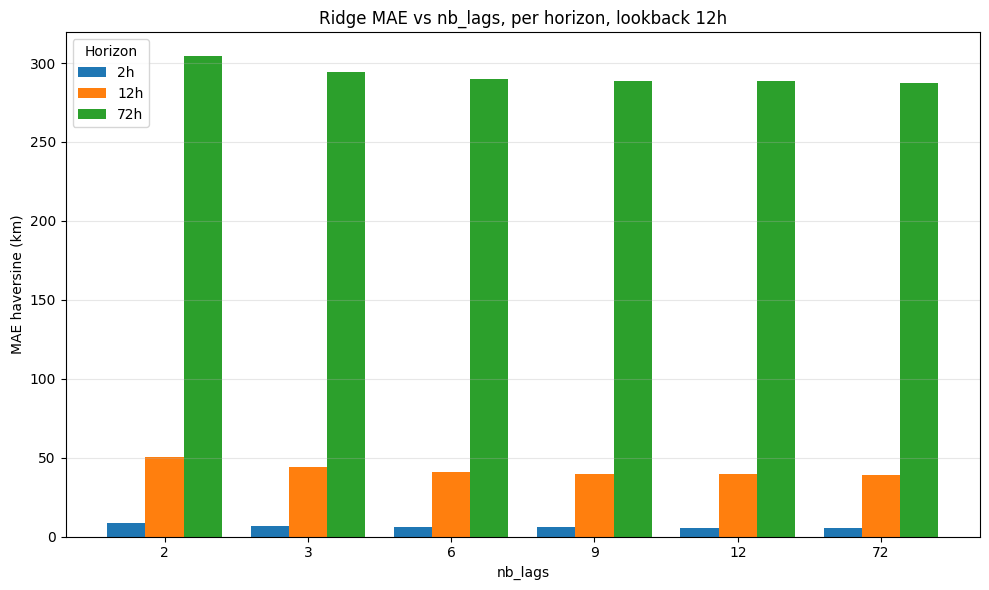

In [68]:
# 3.0 plot: MAE vs nb_lags at each probe horizon.
# nb_lags on a categorical axis (values are non-uniform), one bar group per lag,
# one bar per horizon. flat bars within a horizon = adding lags does not help.

probe_horizons = sorted(lag_sweep_summary["horizon_hours"].unique())
lags = sorted(lag_sweep_summary["nb_lags"].unique())

x = np.arange(len(lags))
width = 0.8 / len(probe_horizons)

fig, ax = plt.subplots(figsize=(10, 6))
for i, h in enumerate(probe_horizons):
    sub = (lag_sweep_summary[lag_sweep_summary["horizon_hours"] == h]
           .set_index("nb_lags").reindex(lags))
    ax.bar(x + i * width, sub["mae_mean"], width, label=f"{h:g}h")

ax.set_xticks(x + width * (len(probe_horizons) - 1) / 2)
ax.set_xticklabels(lags)
ax.set_xlabel("nb_lags")
ax.set_ylabel("MAE haversine (km)")
ax.set_title("Ridge MAE vs nb_lags, per horizon, lookback 12h")
ax.legend(title="Horizon")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [69]:
lag_sweep_summary

,model_name,h,mae_mean,r50_km,r80_km,r90_km,r95_km,nb_lags,horizon_hours
0,Ridge,120,8.383367,3.847205,13.780379,22.384560,30.384983,2,2.0
1,Ridge,720,50.168144,24.497347,81.795239,130.818396,174.973248,2,12.0
2,Ridge,4320,304.268524,183.949524,490.608734,742.278723,952.713528,2,72.0
3,Ridge,120,6.995897,2.961819,11.987625,18.709647,25.562830,3,2.0
4,Ridge,720,44.258915,19.165993,74.363213,117.924945,161.282474,3,12.0
5,Ridge,4320,294.429138,152.337692,492.302228,779.405420,990.588489,3,72.0
6,Ridge,120,6.097947,2.615457,10.784253,16.567254,22.007663,6,2.0
7,Ridge,720,40.630234,16.968828,69.313165,110.724051,151.774313,6,12.0
8,Ridge,4320,289.946350,135.970543,497.198456,801.139648,1006.175290,6,72.0
9,Ridge,120,5.850573,2.557630,10.405787,15.990418,20.952278,9,2.0


### conclusion: nb_lags

MAE drops from 2 to 6 lags: -27% at 2h, -19% at 12h, -5% at 72h. Beyond 6 lags the curve flattens. Going from 6 to 72 lags increase perf by at most 9% (at 2h, worth 0.5 km) and under 1% at 72h. In absolute terms the residual gain stays within a few km.

That gain does not justify its cost. nb_lags=72 means 12x more features, and not sustainable on some devices.

nb_lags is fixed at 6 downstream. It captures nearly all the MAE signal at every horizon while keeping the model cheap to fit and serve. At 72h the R90 tail does not improve with more lags.


### 3.1 Main evaluation, lookback 12h with different nb_lags


In [70]:
lookback = 12
horizon_grid_hours = [2, 4, 6, 8, 10, 12, 24, 48, 72]
LAG_REF = 6  # retained nb_lags (from §3.0); used by graphs/tables below and 3h section
FORCE_RECOMPUTE = False  # set True to refit even if cached outputs exist

horizon_grid_minutes = [h * 60 for h in horizon_grid_hours]

out_dir = Path("outputs")
summary_path_12h = out_dir / "ridge_summary_12h.csv"
oof_path_12h = out_dir / "ridge_oof_12h.parquet"

if not FORCE_RECOMPUTE and summary_path_12h.exists() and oof_path_12h.exists():
    print("Cached 12h results found, loading from disk (set FORCE_RECOMPUTE=True to refit).")
    summary_12h = pd.read_csv(summary_path_12h)
    oof_ref_12h = pd.read_parquet(oof_path_12h)
    
else:
    df_lag = create_lag_features(df=df_trainval, nb_lags=LAG_REF, lookback_minutes=lookback*60)
    df_lag = create_heading_features(df=df_lag)
    df_lag = create_target(df=df_lag, horizon_grid_minutes=horizon_grid_minutes)

    oof_ref_12h, _ = run_crossval(
        df=df_lag, model=ridge_model, model_name="Ridge",
        lookback_minutes=lookback*60, with_baseline=True,
    )

    summary_12h = compute_metrics(oof_ref_12h)
    summary_12h["nb_lags"] = LAG_REF
    summary_12h["horizon_hours"] = summary_12h["h"] / 60


Cached 12h results found, loading from disk (set FORCE_RECOMPUTE=True to refit).


In [71]:
out_dir.mkdir(parents=True, exist_ok=True)
summary_12h.to_csv(summary_path_12h, index=False)
oof_ref_12h.to_parquet(oof_path_12h, index=False)


### 3.2 Results

Check how the Ridge model is performing compare to baseline at various prediction horizon using the model metrics (MAE) and the operational metric (Rp,h)

#### MAE

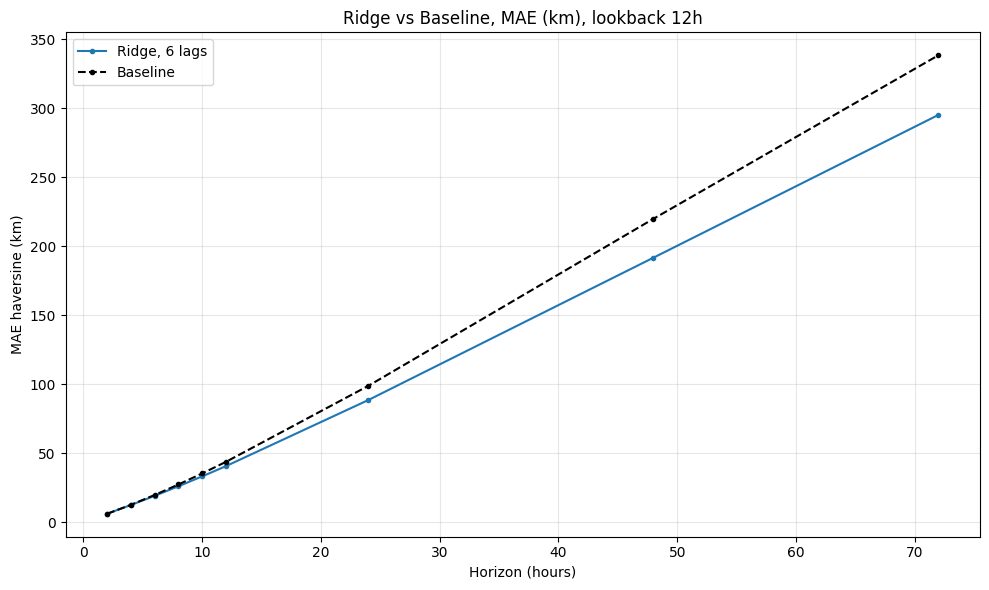

In [72]:
# --- Graph 1: MAE (km) vs horizon ---
fig, ax = plt.subplots(figsize=(10, 6))

ridge_df = summary_12h[summary_12h["model_name"] == "Ridge"]
for nb_lags_i in sorted(ridge_df["nb_lags"].unique()):
    subset = ridge_df[ridge_df["nb_lags"] == nb_lags_i].sort_values("horizon_hours")
    ax.plot(subset["horizon_hours"], subset["mae_mean"], marker="o", markersize=3,
            linestyle="-", label=f"Ridge, {nb_lags_i} lags")

baseline_df = summary_12h[summary_12h["model_name"] == "Baseline"].sort_values("horizon_hours")
ax.plot(baseline_df["horizon_hours"], baseline_df["mae_mean"], marker="o", markersize=3,
        linestyle="--", color="black", label="Baseline")

ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("MAE haversine (km)")
ax.set_title("Ridge vs Baseline, MAE (km), lookback 12h")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

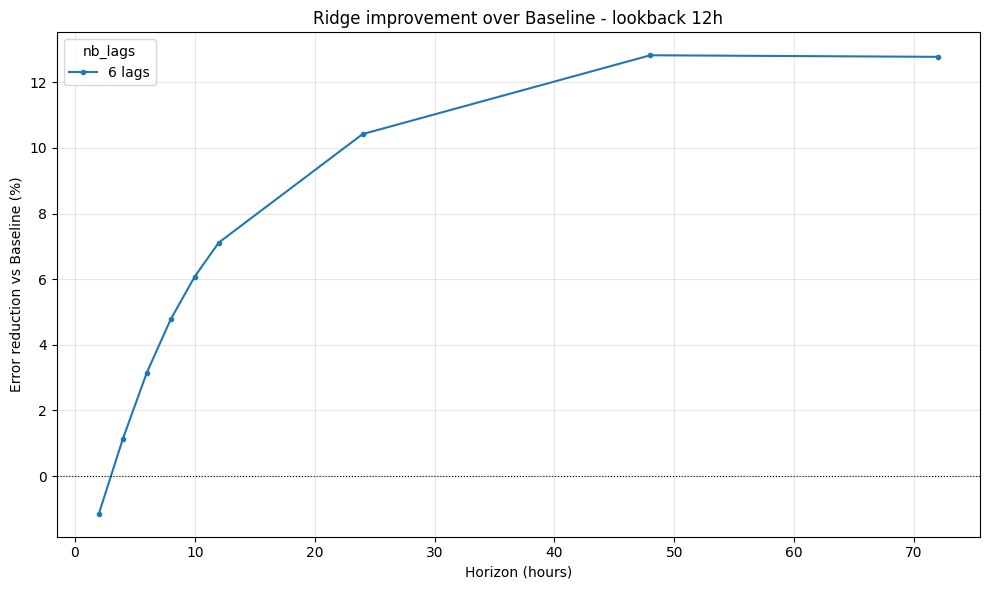

In [73]:
# --- Graph 2: improvement over Baseline (%) ---
baseline_lookup = baseline_df.set_index("horizon_hours")["mae_mean"]

fig, ax = plt.subplots(figsize=(10, 6))
for nb_lags_i in sorted(ridge_df["nb_lags"].unique()):
    subset = ridge_df[ridge_df["nb_lags"] == nb_lags_i].sort_values("horizon_hours")
    mae_baseline = subset["horizon_hours"].map(baseline_lookup)
    improvement_pct = (mae_baseline - subset["mae_mean"]) / mae_baseline * 100
    ax.plot(subset["horizon_hours"], improvement_pct, marker="o", markersize=3,
            linestyle="-", label=f"{nb_lags_i} lags")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Error reduction vs Baseline (%)")
ax.set_title("Ridge improvement over Baseline - lookback 12h")
ax.legend(title="nb_lags")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MAE alone is not the operational metric for this project. Ridge's improvement over baseline is small and roughly monotonic with horizon: slightly negative at 2h, crossing positive by 4h, reaching about 13 percent by 48 to 72h.

###  Uncertainty radius, R(p,h) vs baseline

R90 (bold) is the primary read: the radius containing 90% of residuals at each horizon. The baseline R90 (dashed black) is the reference : a model curve at or above it means the model adds no value at that level, regardless of its MAE. The dotted horizontal line marks the 10 NM benchmark (see NB01) as an external, horizon-independent benchmark.


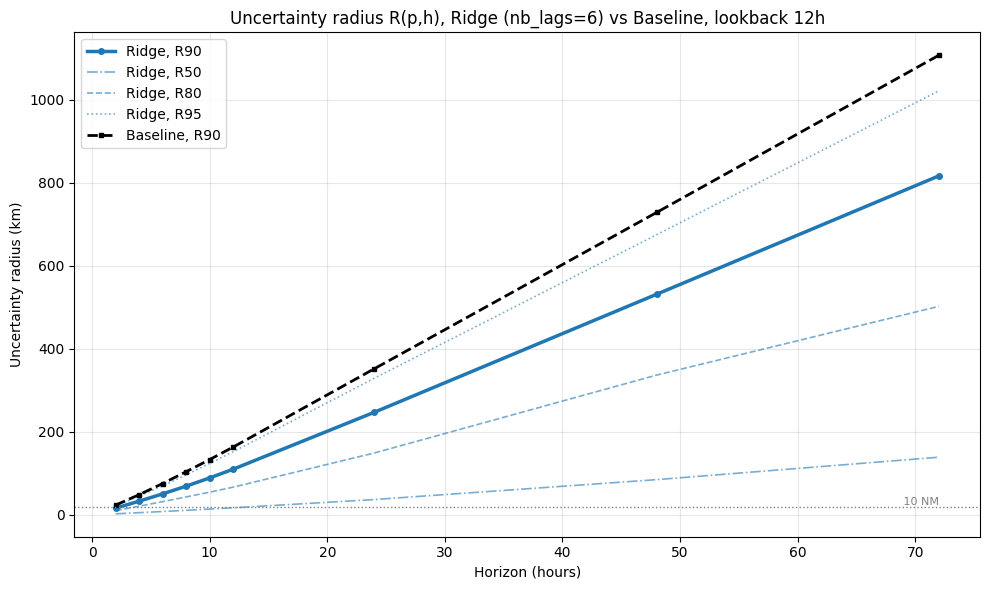

In [74]:
# --- Graph 3: uncertainty radius R(p,h), Ridge (nb_lags=6) vs Baseline ---
NM_TO_KM = 1.852

ridge_r = summary_12h[
    (summary_12h["model_name"] == "Ridge") & (summary_12h["nb_lags"] == LAG_REF)
].sort_values("horizon_hours")

baseline_r = summary_12h[summary_12h["model_name"] == "Baseline"].sort_values("horizon_hours")

fig, ax = plt.subplots(figsize=(10, 6))

# Ridge, R90 bold; R50 / R80 / R95 lighter
ax.plot(ridge_r["horizon_hours"], ridge_r["r90_km"], color="C0", linewidth=2.5,
        marker="o", markersize=4, label="Ridge, R90")
ax.plot(ridge_r["horizon_hours"], ridge_r["r50_km"], color="C0", linewidth=1.2,
        linestyle="-.", alpha=0.6, label="Ridge, R50")
ax.plot(ridge_r["horizon_hours"], ridge_r["r80_km"], color="C0", linewidth=1.2,
        linestyle="--", alpha=0.6, label="Ridge, R80")
ax.plot(ridge_r["horizon_hours"], ridge_r["r95_km"], color="C0", linewidth=1.2,
        linestyle=":", alpha=0.6, label="Ridge, R95")

# Baseline, R90 only, dashed black
ax.plot(baseline_r["horizon_hours"], baseline_r["r90_km"], color="black", linewidth=2,
        linestyle="--", marker="s", markersize=3, label="Baseline, R90")

# SAR reference line (10 NM)
ax.axhline(10 * NM_TO_KM, color="gray", linestyle=":", linewidth=1)
ax.text(ridge_r["horizon_hours"].max(), 10 * NM_TO_KM, " 10 NM", va="bottom", ha="right", fontsize=8, color="gray")

ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Uncertainty radius (km)")
ax.set_title(f"Uncertainty radius R(p,h), Ridge (nb_lags={LAG_REF}) vs Baseline, lookback 12h")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


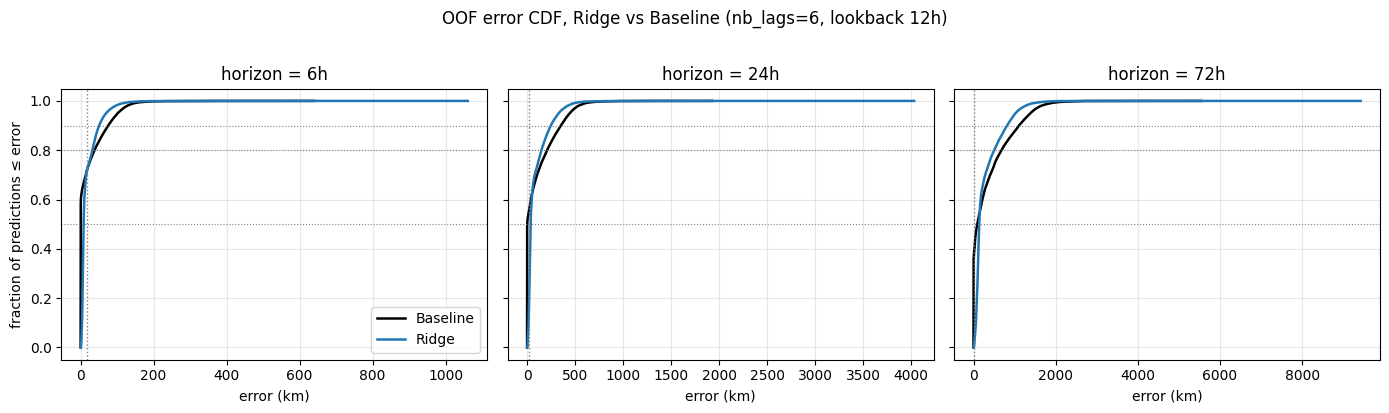

In [55]:
# --- Graph 4: OOF error CDF, Ridge (nb_lags=6) vs Baseline, lookback 12h ---
# ECDF reads percentiles directly (R90 = intersection with y=0.90) and shows the tail.
CDF_HORIZONS = [6, 24, 72]
NM10_KM = 10 * 1.852  # IAMSAR default search radius, 10 NM

fig, axes = plt.subplots(1, len(CDF_HORIZONS), figsize=(14, 4), sharey=True)
for ax, h in zip(axes, CDF_HORIZONS):
    sub = oof_ref_12h[oof_ref_12h["h"] == h * 60]
    for model_name, color in [("Baseline", "black"), ("Ridge", "C0")]:
        errors = np.sort(sub.loc[sub["model_name"] == model_name, "error_km"].values)
        cdf = np.arange(1, len(errors) + 1) / len(errors)
        ax.plot(errors, cdf, color=color, linewidth=1.8, label=model_name)
    ax.axvline(NM10_KM, color="gray", linestyle=":", linewidth=1)
    for q in (0.5, 0.8, 0.9):
        ax.axhline(q, color="gray", linestyle=":", linewidth=0.8)
    ax.set_title(f"horizon = {h}h")
    ax.set_xlabel("error (km)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("fraction of predictions ≤ error")
axes[0].legend()
fig.suptitle("OOF error CDF, Ridge vs Baseline (nb_lags=6, lookback 12h)", y=1.02)
plt.tight_layout()
plt.show()


In [75]:
# Table: horizon × R50/R80/R90/R95 (km), Ridge (nb_lags=6) vs Baseline
radius_tbl = (
    summary_12h[
        (
            ((summary_12h["model_name"] == "Ridge") & (summary_12h["nb_lags"] == LAG_REF))
            | (summary_12h["model_name"] == "Baseline")
        )
    ]
    .pivot_table(
        index="horizon_hours",
        columns="model_name",
        values=["r50_km", "r80_km", "r90_km", "r95_km"],
        aggfunc="first",
    )
    .sort_index()
    .round(2)
)
# MultiIndex columns (radius, model), readable as-is
radius_tbl = radius_tbl.reindex(
    columns=pd.MultiIndex.from_product(
        [["r50_km", "r80_km", "r90_km", "r95_km"], ["Baseline", "Ridge"]]
    )
)
radius_tbl


r50_km           r80_km           r90_km           r95_km  \
              Baseline   Ridge Baseline   Ridge Baseline   Ridge Baseline   
horizon_hours                                                               
2.0               0.01    2.63    10.57   10.19    23.43   16.12    32.79   
4.0               0.01    5.35    23.59   20.87    48.64   33.03    66.24   
6.0               0.03    8.14    37.98   31.97    75.51   50.61   101.46   
8.0               0.05   11.02    53.75   43.28   103.96   69.21   137.89   
10.0              0.09   14.00    70.63   54.74   133.35   89.04   174.88   
12.0              0.14   17.07    88.57   66.80   163.40  110.09   212.79   
24.0              1.72   36.96   208.23  149.14   352.13  247.30   444.60   
48.0             40.24   84.92   465.16  336.85   728.72  531.59   910.45   
72.0             90.88  139.00   682.53  502.50  1107.55  816.88  1384.45   

                        
                 Ridge  
horizon_hours           
2.0              21.75  
4.0              45.10  
6.0              69.89  
8.0              96.43  
10.0            124.07  
12.0            152.11  
24.0            329.35  
48.0            675.10  
72.0           1021.77

Ridge reduces the search area at every horizon, but the reduction does not grow with horizon. Since search area scales with R90 squared, the R90 values in the table above give an area reduction of roughly 55 percent at 12h, 51 percent at 24h, 47 percent at 48h and 46 percent at 72h. The gain is real and roughly constant across horizons.

Even so, Ridge R90 crosses above the 10 NM reference by about 4h. Beyond that horizon the operational radius exceeds the immediate-search default whichever predictor is used. 

Splitting the error distribution by percentile provides important insight. The baseline has more low-error mass (R50 is lower for baseline than for Ridge). In the extreme tail, Ridge also performs way worse: its worst-case error at 72h reaches 9422 km against 5538 km for the baseline. This is likely because the baseline is bounded by construction, whereas the Ridge model could in principle predict anything.

So, Ridge's overall gain appears concentrated on the mid-to-upper percentiles (R80-R95), not at the extremes: at R50 the baseline still comes out ahead, and at the very top of the distribution Ridge occasionally fails outright with absurd predictions. Note this compares two percentile distributions computed independently per model: it shows the two error distributions have a different shape, not that the same tracks are easy or hard for both models.


## 4. Conclusion

- Number of lags has no marked effect. More lags raise the percentage gain over baseline but the raw km difference stays small, with the plateau reached around 6 lags. Using 72 lags, effectively the whole trajectory, does not help further, so the ceiling is not a lack of trajectory information.
- On MAE, Ridge's improvement over baseline increases with horizon and stays modest: about -1 percent at 2h, crossing to positive gains by 4h, reaching about 13 percent by 48 to 72h.
- The R90 shows Ridge reduces the search area by close to half at every horizon from 12h onward, and this reduction does not grow with horizon. See section 3.2 for the percentile breakdown and its limits.
- However, Ridge's errors are still high at the low and extreme-high ends of the error distribution, even though it does better in between (see section 3.2 for the percentile breakdown and its limits).
- This performance ceiling isn't explained by trajectory history (lag sweep, section 3.0) or by regularization strength (Appendix 5.2, MAE flat from alpha 0.01 to 100). We consider that it is a limit of what a global linear map from features to velocity can express. This motivates testing a non-linear model next, LGBM in NB05.


In [76]:
# === Recap: Ridge vs Baseline at the retained operating point (lookback 12h, LAG_REF lags) ===
ridge_op = (
    summary_12h[(summary_12h["model_name"] == "Ridge") & (summary_12h["nb_lags"] == LAG_REF)]
    .set_index("horizon_hours")
)
baseline_op = summary_12h[summary_12h["model_name"] == "Baseline"].set_index("horizon_hours")

recap_12h = pd.DataFrame({
    "mae_baseline_km": baseline_op["mae_mean"],
    "mae_ridge_km": ridge_op["mae_mean"],
})
recap_12h["improvement_pct"] = (
    (recap_12h["mae_baseline_km"] - recap_12h["mae_ridge_km"]) / recap_12h["mae_baseline_km"] * 100
)
# mae_std_ridge_km dropped: compute_metrics has no per-fold std, only pooled mae_mean/percentiles
recap_12h = recap_12h.round({"mae_baseline_km": 2, "mae_ridge_km": 2, "improvement_pct": 1})
recap_12h


,mae_baseline_km,mae_ridge_km,improvement_pct
horizon_hours,,,
2.0,5.95,6.02,-1.2
4.0,12.49,12.35,1.1
6.0,19.61,18.99,3.2
8.0,27.22,25.92,4.8
10.0,35.25,33.11,6.1
12.0,43.63,40.53,7.1
24.0,98.81,88.51,10.4
48.0,219.94,191.73,12.8
72.0,338.56,295.31,12.8


In [77]:
(oof_ref_12h[oof_ref_12h["h"] == 4320]
 .groupby("model_name")["error_km"]
 .quantile([0.95, 0.99, 0.999, 1.0]))

model_name       
Baseline    0.950    1384.446301
            0.990    1857.717806
            0.999    2493.429246
            1.000    5538.418945
Ridge       0.950    1021.773041
            0.990    1428.634746
            0.999    2006.318115
            1.000    9422.018555
Name: error_km, dtype: float64

## Appendix


### Spot Check lookback 3h


In [46]:

lookback = 3
horizon_grid_hours = [2, 6, 8, 10, 12, 24, 48, 72]
candidates_lag = [2, 6, 18]
horizon_grid_minutes = [h * 60 for h in horizon_grid_hours]
FORCE_RECOMPUTE = False  # set True to refit even if cached output exists

out_dir = Path("outputs")
summary_path_3h = out_dir / "ridge_summary_3h.csv"

if not FORCE_RECOMPUTE and summary_path_3h.exists():
    print("Cached 3h summary found, loading from disk (set FORCE_RECOMPUTE=True to refit).")
    summary_3h = pd.read_csv(summary_path_3h)
else:
    # baseline does not depend on nb_lags; only ask for it once, at nb_lags == LAG_REF.
    # Aggregate inside the loop instead of stacking full per-row oof_df across all
    # nb_lags; the 3h sweep has no CDF, so no per-row detail needs to be kept at all.
    summary_parts_3h = []

    for lag in candidates_lag:
        print(f"testing lag {lag}")

        df_lag = create_lag_features(df=df_trainval, nb_lags=lag, lookback_minutes=lookback * 60)
        df_lag = create_heading_features(df=df_lag)
        df_lag = create_target(df=df_lag, horizon_grid_minutes=horizon_grid_minutes)

        oof_df, _ = run_crossval(
            df=df_lag, model=ridge_model, model_name="Ridge",
            lookback_minutes=lookback * 60, with_baseline=(lag == LAG_REF),
        )

        summary_lag_3h = compute_metrics(oof_df)
        summary_lag_3h["nb_lags"] = lag
        summary_parts_3h.append(summary_lag_3h)

    summary_3h = pd.concat(summary_parts_3h, ignore_index=True)
    summary_3h["horizon_hours"] = summary_3h["h"] / 60
        
        
        


Cached 3h summary found, loading from disk (set FORCE_RECOMPUTE=True to refit).


In [47]:
# summary_3h is now built directly in the loop above, per nb_lags,
# to avoid stacking full per-row oof_df across all nb_lags in memory
out_dir = Path("outputs")
out_dir.mkdir(parents=True, exist_ok=True)
summary_path_3h = out_dir / "ridge_summary_3h.csv"
summary_3h.to_csv(summary_path_3h, index=False)


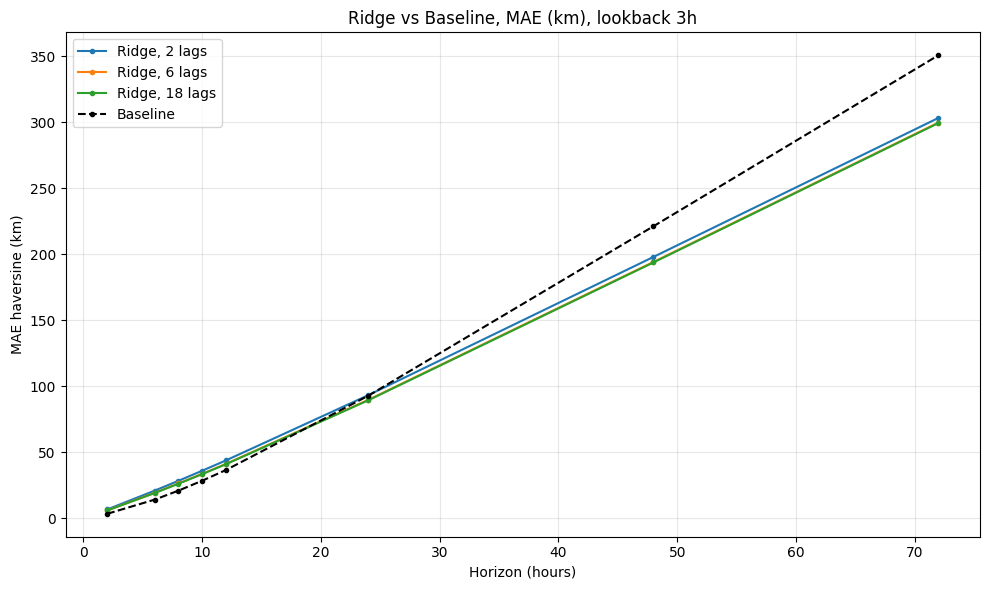

In [48]:
# --- Graph 1: MAE (km) vs horizon ---
fig, ax = plt.subplots(figsize=(10, 6))

ridge_df = summary_3h[summary_3h["model_name"] == "Ridge"]
for nb_lags_i in sorted(ridge_df["nb_lags"].unique()):
    subset = ridge_df[ridge_df["nb_lags"] == nb_lags_i].sort_values("horizon_hours")
    ax.plot(subset["horizon_hours"], subset["mae_mean"], marker="o", markersize=3,
            linestyle="-", label=f"Ridge, {nb_lags_i} lags")

baseline_df = summary_3h[summary_3h["model_name"] == "Baseline"].sort_values("horizon_hours")
ax.plot(baseline_df["horizon_hours"], baseline_df["mae_mean"], marker="o", markersize=3,
        linestyle="--", color="black", label="Baseline")

ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("MAE haversine (km)")
ax.set_title("Ridge vs Baseline, MAE (km), lookback 3h")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

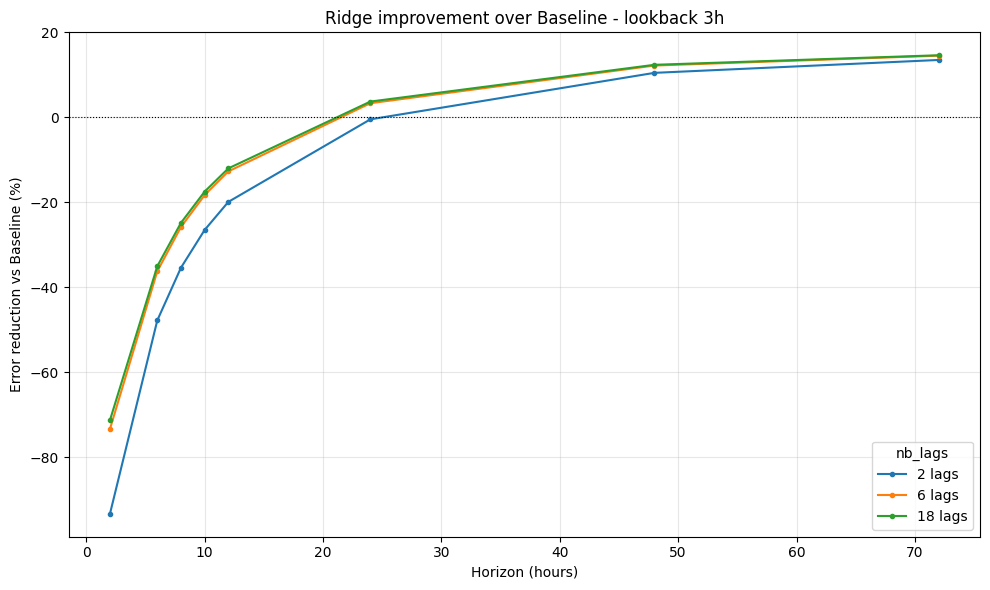

In [49]:
# --- Graph 2: improvement over Baseline (%) ---
baseline_lookup = baseline_df.set_index("horizon_hours")["mae_mean"]

fig, ax = plt.subplots(figsize=(10, 6))
for nb_lags_i in sorted(ridge_df["nb_lags"].unique()):
    subset = ridge_df[ridge_df["nb_lags"] == nb_lags_i].sort_values("horizon_hours")
    mae_baseline = subset["horizon_hours"].map(baseline_lookup)
    improvement_pct = (mae_baseline - subset["mae_mean"]) / mae_baseline * 100
    ax.plot(subset["horizon_hours"], improvement_pct, marker="o", markersize=3,
            linestyle="-", label=f"{nb_lags_i} lags")

ax.axhline(0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Error reduction vs Baseline (%)")
ax.set_title("Ridge improvement over Baseline - lookback 3h")
ax.legend(title="nb_lags")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

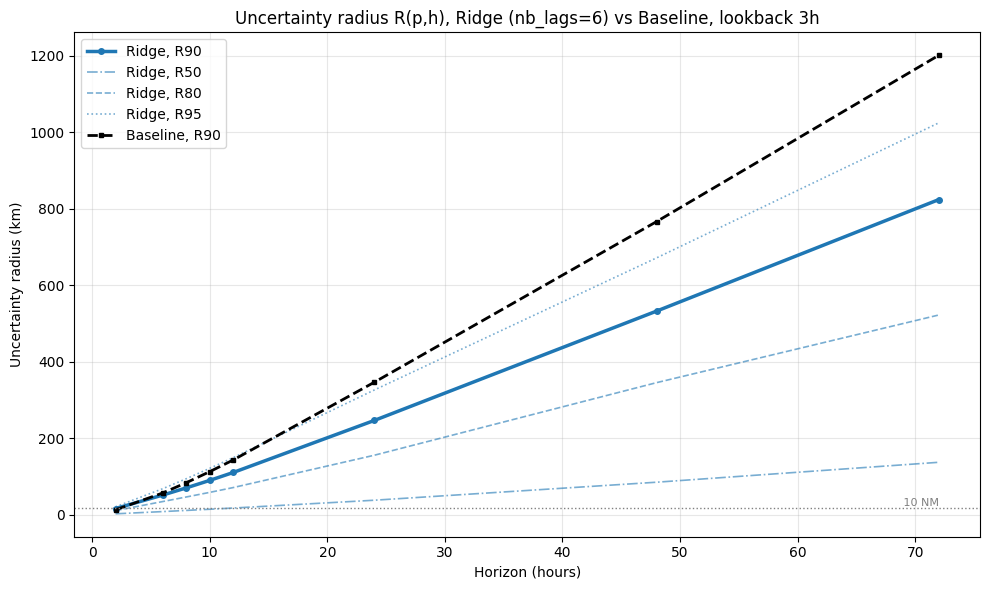

In [50]:
# --- Graph 3: uncertainty radius R(p,h), Ridge (nb_lags=6) vs Baseline, lookback 3h ---
NM_TO_KM = 1.852

ridge_r = summary_3h[
    (summary_3h["model_name"] == "Ridge") & (summary_3h["nb_lags"] == LAG_REF)
].sort_values("horizon_hours")

baseline_r = summary_3h[summary_3h["model_name"] == "Baseline"].sort_values("horizon_hours")

fig, ax = plt.subplots(figsize=(10, 6))

# Ridge, R90 bold; R50 / R80 / R95 lighter
ax.plot(ridge_r["horizon_hours"], ridge_r["r90_km"], color="C0", linewidth=2.5,
        marker="o", markersize=4, label="Ridge, R90")
ax.plot(ridge_r["horizon_hours"], ridge_r["r50_km"], color="C0", linewidth=1.2,
        linestyle="-.", alpha=0.6, label="Ridge, R50")
ax.plot(ridge_r["horizon_hours"], ridge_r["r80_km"], color="C0", linewidth=1.2,
        linestyle="--", alpha=0.6, label="Ridge, R80")
ax.plot(ridge_r["horizon_hours"], ridge_r["r95_km"], color="C0", linewidth=1.2,
        linestyle=":", alpha=0.6, label="Ridge, R95")

# Baseline, R90 only, dashed black
ax.plot(baseline_r["horizon_hours"], baseline_r["r90_km"], color="black", linewidth=2,
        linestyle="--", marker="s", markersize=3, label="Baseline, R90")

# SAR reference line (10 NM)
ax.axhline(10 * NM_TO_KM, color="gray", linestyle=":", linewidth=1)
ax.text(ridge_r["horizon_hours"].max(), 10 * NM_TO_KM, " 10 NM", va="bottom", ha="right", fontsize=8, color="gray")

ax.set_xlabel("Horizon (hours)")
ax.set_ylabel("Uncertainty radius (km)")
ax.set_title(f"Uncertainty radius R(p,h), Ridge (nb_lags={LAG_REF}) vs Baseline, lookback 3h")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [51]:
# Table: horizon × R50/R80/R90/R95 (km), Ridge (nb_lags=6) vs Baseline, lookback 3h
radius_tbl_3h = (
    summary_3h[
        (
            ((summary_3h["model_name"] == "Ridge") & (summary_3h["nb_lags"] == LAG_REF))
            | (summary_3h["model_name"] == "Baseline")
        )
    ]
    .pivot_table(
        index="horizon_hours",
        columns="model_name",
        values=["r50_km", "r80_km", "r90_km", "r95_km"],
        aggfunc="first",
    )
    .sort_index()
    .round(2)
)
radius_tbl_3h = radius_tbl_3h.reindex(
    columns=pd.MultiIndex.from_product(
        [["r50_km", "r80_km", "r90_km", "r95_km"], ["Baseline", "Ridge"]]
    )
)
radius_tbl_3h


r50_km           r80_km           r90_km           r95_km  \
              Baseline   Ridge Baseline   Ridge Baseline   Ridge Baseline   
horizon_hours                                                               
2.0               0.00    2.76     2.99   11.19    13.14   16.58    24.20   
6.0               0.01    8.53    20.77   34.72    57.08   51.64    85.88   
8.0               0.01   11.55    34.84   46.64    83.87   70.40   120.85   
10.0              0.02   14.63    50.26   58.72   112.88   90.05   157.56   
12.0              0.03   17.80    67.98   71.33   143.41  110.74   196.21   
24.0              0.46   38.25   195.79  155.87   346.71  246.84   441.06   
48.0             29.16   85.34   476.10  345.66   766.75  532.75   947.43   
72.0             66.94  137.45   720.93  522.59  1201.66  824.35  1466.13   

                        
                 Ridge  
horizon_hours           
2.0              21.10  
6.0              68.27  
8.0              94.29  
10.0            121.58  
12.0            149.47  
24.0            326.46  
48.0            671.90  
72.0           1025.02

### Check whether regularization has an impact


In [52]:
# Sweep alpha on a SINGLE (horizon, nb_lags) pair, not the whole grid.
# If MAE is flat over several orders of magnitude of alpha, regularization has no bite.


H_PROBE = 24          # test horizon (hours), a representative mid-range horizon
NB_LAGS_PROBE = 6     # nb_lags at the parsimony plateau
LOOKBACK_PROBE = 12    # hours

alphas = [0.01, 1, 100, 1e4, 1e6]

df_probe = create_lag_features(df=df_trainval, nb_lags=NB_LAGS_PROBE, lookback_minutes=LOOKBACK_PROBE * 60)
df_probe = create_heading_features(df=df_probe)
df_probe = create_target(df=df_probe, horizon_grid_minutes=[H_PROBE * 60])

alpha_results = []
for a in alphas:
    model_a = Pipeline([("scaler", RobustScaler()), ("model", Ridge(alpha=a))])
    oof_df, _ = run_crossval(
        df=df_probe, model=model_a, model_name=f"Ridge_alpha_{a:g}",
        lookback_minutes=LOOKBACK_PROBE * 60, with_baseline=False,
    )
    metrics = compute_metrics(oof_df)
    row = metrics.iloc[0]  # single model, single horizon -> exactly one row
    alpha_results.append({"alpha": a, "mae_mean": row["mae_mean"]})

alpha_df = pd.DataFrame(alpha_results)
print(alpha_df.to_string(index=False))

     alpha   mae_mean
      0.01  94.272560
      1.00  93.871254
    100.00  93.634232
  10000.00 105.749252
1000000.00 114.669624


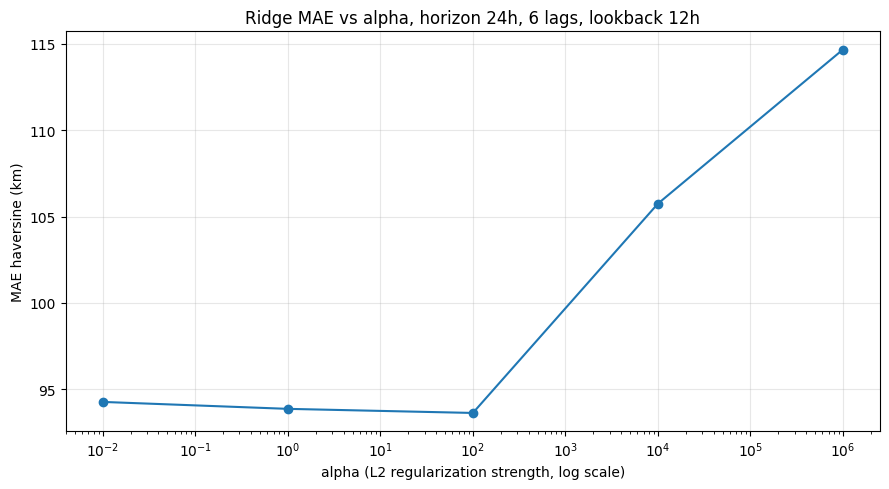

In [53]:
fig, ax = plt.subplots(figsize=(9, 5))
# no yerr: compute_metrics has no per-fold std, only pooled mae_mean/percentiles
ax.plot(alpha_df["alpha"], alpha_df["mae_mean"], marker="o", linestyle="-")
ax.set_xscale("log")
ax.set_xlabel("alpha (L2 regularization strength, log scale)")
ax.set_ylabel("MAE haversine (km)")
ax.set_title(f"Ridge MAE vs alpha, horizon {H_PROBE}h, {NB_LAGS_PROBE} lags, lookback {LOOKBACK_PROBE}h")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Default alpha for ridge: 1.0: Neither 0.01 nor 100 of alpha has an impact indicating that we don't have a lack of regularization issue. 

### Effect of the lookback duration


In [54]:
# === Lookback effect ===
lookback_files = {3: "outputs/ridge_summary_3h.csv",  12: "outputs/ridge_summary_12h.csv"}
horizons_probe = [2, 8, 12, 24, 48, 72]  # intersection of the 3h and 12h horizon grids

rows = []
for h in horizons_probe:
    row = {"horizon": h}
    for lb, f in lookback_files.items():
        d = pd.read_csv(f)
        row[f"baseline_{lb}h"] = round(
            d[(d["model_name"] == "Baseline") & (d["horizon_hours"] == h)]["mae_mean"].values[0], 1
        )
        row[f"ridge_{lb}h"] = round(
            d[(d["model_name"] == "Ridge") & (d["nb_lags"] == LAG_REF) & (d["horizon_hours"] == h)]["mae_mean"].values[0], 1
        )
    rows.append(row)

lookback_effect = pd.DataFrame(rows).set_index("horizon")
lookback_effect = lookback_effect[
    [f"baseline_{lb}h" for lb in [3, 12]] + [f"ridge_{lb}h" for lb in [3, 12]]
]
lookback_effect

,baseline_3h,baseline_12h,ridge_3h,ridge_12h
horizon,,,,
2,3.5,6.0,6.1,6.0
8,21.1,27.2,26.5,25.9
12,36.7,43.6,41.3,40.5
24,93.0,98.8,89.9,88.5
48,221.3,219.9,194.3,191.7
72,350.8,338.6,299.8,295.3


increasing the lookback doesn't improve the model, it makes the baseline worse for most of the horizons.. Logical: in a 12h lookback window, the baseline extrapolate a future position based on a past position 12h old. More vessels may have changed course during this 12h.  